# <center> Сопряженные распределения и экспоненциальный класс рапределений</center>


<img src='https://j-g-b.github.io/assets/img/conjugate_priors.jpeg'></img>

## Теоретические задачи

## Задача 1

Рассмотрим гамма-распределение:

$$\mathcal{G}(x | a, b) = \frac{b^a}{\Gamma(a)}x^{a-1}\exp(-bx)$$

Запишите его как представителя экспоненциального семейства, найдите $\mathbb{E}x$ и $\mathbb{E}\log x$ путем дифференцирования логарифма нормировочной константы


## Задача 2

Рассмотрим биномиальное распределение:

$$Binomial(x | p) = C_N^x p^x(1-p)^{N-x}$$

Запишите его как представителя экспоненциального семейства, найдите матожидание и дисперсию путем дифференцирования логарифма нормировочной константы

## Практические задачи

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import scipy
from IPython.display import clear_output

## Задача 3. Монетка

Пусть дана монетка, у которой неизвестна вероятность выпадения орла. Оценить эту вероятность, проведя серию экспериментов

In [2]:
class Coin() :
    def __init__(self):
        self.p = np.random.uniform(0, 1.)
        
    def sample(self):
        return np.random.choice([1, 0], p = [self.p, 1-self.p])

### Бета-распределение

$$Beta(x | a, b) = \frac{1}{B(a, b)} x^{a-1} (1-x)^{b-1}$$

In [3]:
prob_beta = lambda x, a, b: 1 / scipy.special.beta(a, b) * x**(a-1) * (1-x)**(b-1)

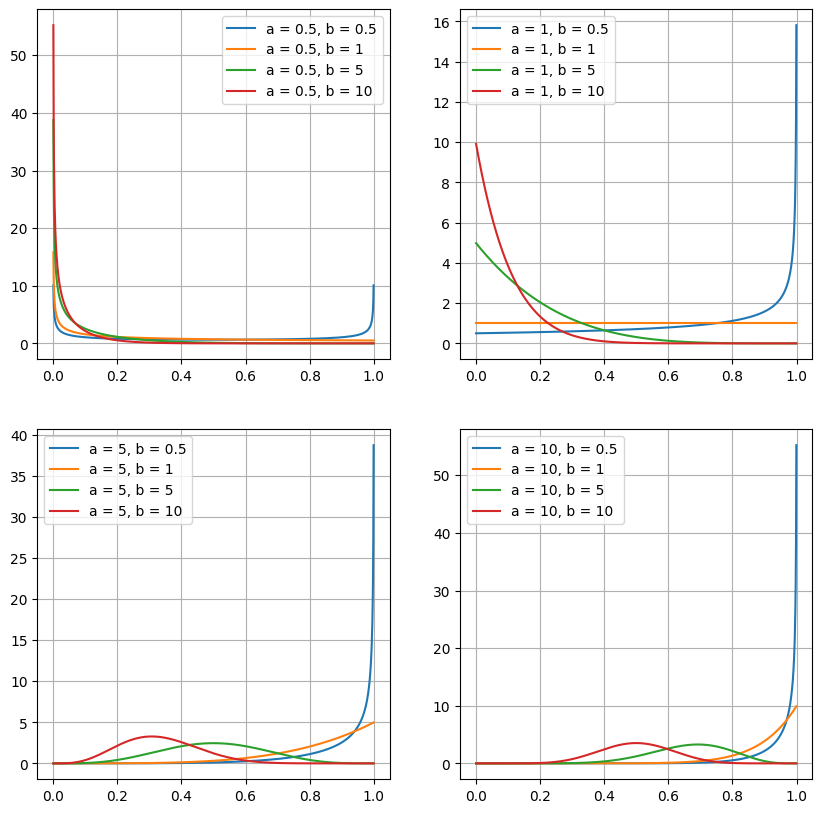

In [4]:
plt.figure(figsize=(10,10))
x = np.linspace(0.001, 0.999, 1000)
for i, a in enumerate([0.5, 1, 5, 10]):
    plt.subplot(2, 2, i+1)
    for b in [0.5, 1, 5, 10]:
        plt.plot(x, prob_beta(x, a, b), label='a = {}, b = {}'.format(a, b))
    plt.legend()
    plt.grid()

Заметим, что форма распределения зависит от соотношения между a и b: если a превосходит b, то мода распределения смещается к единице, если наоборот -- то к нулю, а если параметры равны, то распределение симметрично (с одной модой по центру или двумя на концах носителя).

In [5]:
def get_posterior(values, a, b):
    a_post = a + np.sum(values)
    b_post = b + len(values) - np.sum(values)
    return a_post, b_post

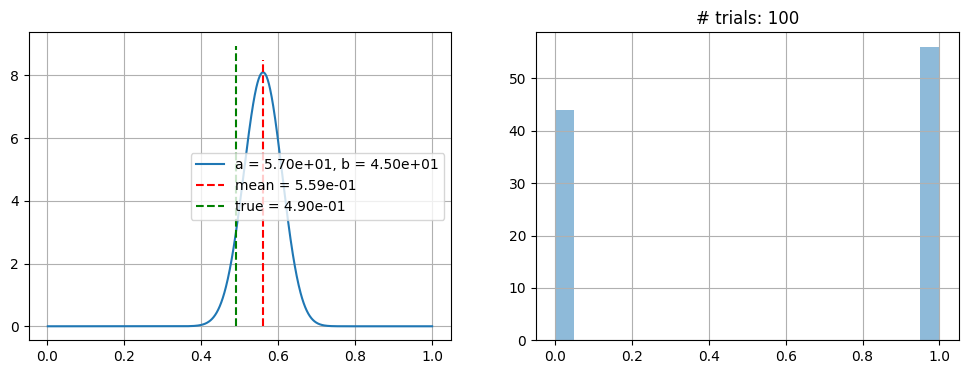

In [6]:
coin = Coin()
values = []
a = 1
b = 1
for idx in range (100):
    clear_output(True)
    plt.figure(figsize=(12, 4))
    sample = coin.sample()
    values.append(sample)
    a, b = get_posterior([sample], a, b)
    plt.subplot(1,2,1)
    x = np.linspace(0.001, 0.999, 1000)
    plt.plot(x, prob_beta(x, a, b), label='a = {0:.2e}, b = {1:.2e}'.format(a, b))
    p_bayes = a/(b + a)
    plt.vlines(p_bayes, 0, plt.gca().get_ylim()[1], linestyle='--', label='mean = {0:.2e}'.format(p_bayes), color='r')
    plt.vlines(coin.p, 0, plt.gca().get_ylim()[1], linestyle='--', label='true = {0:.2e}'.format(coin.p), color='g')
    plt.grid(True)
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(values,  bins=20, alpha=0.5)
    x = np.linspace(0.01, 1000, 2000)
    plt.grid(True)
    plt.title("# trials: {}".format(len(values)))
    plt.show()

## Задача 4. Средний чек

Пусть мы открыли три небольших магазина A, B и C и стали собирать [данные](https://www.kaggle.com/aungpyaeap/supermarket-sales) о покупках, совершенных в этих магазинах. Так же мы знаем, что в магазинах наших конкурентов покупатель в среднем тратит 200-300 долларов. Мы хотим в режиме реального времени оценивать (по байесовски!) сколько денег в среднем один покупатель тратит в каждом из наших магазинов. 

Посмотрим на данные

In [7]:
!wget https://www.dropbox.com/s/zrj96aysg31p6rc/supermarket_sales%20-%20Sheet1.csv?raw=1

--2025-11-22 10:15:08--  https://www.dropbox.com/s/zrj96aysg31p6rc/supermarket_sales%20-%20Sheet1.csv?raw=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.70.18
Connecting to www.dropbox.com (www.dropbox.com)|162.125.70.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/kbh6tstptknix0t2gtw7q/supermarket_sales-Sheet1.csv?rlkey=ininrcwboq5skzi01oxunzqgz&raw=1 [following]
--2025-11-22 10:15:09--  https://www.dropbox.com/scl/fi/kbh6tstptknix0t2gtw7q/supermarket_sales-Sheet1.csv?rlkey=ininrcwboq5skzi01oxunzqgz&raw=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc9c21d5151c9180fb12b1c929f9.dl.dropboxusercontent.com/cd/0/inline/C1q_SeBTSc6RjGbxghPfwk-z_JKepXRNqFJ225odWlwv3t-LQauVLauOn9qFhl5LQBgInrW3FJ3ZRuCdM2cwVptnqa-sBkYQIAxWNOdsk-iguzj0di-MrJVGXLRAjZYEJP2rFPjcI-HUGawEGK7Mfjdo/file# [following]
--2025-11-22 10:15:09--  https://uc9c21d5151c9180fb12b1

In [8]:
data = pd.read_csv('supermarket_sales - Sheet1.csv?raw=1')

In [9]:
data

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


Информация о сумме чека находится в колонке ```Total```, дата покупки в колонке ```Date```, время в ```Time```. Для удобства совместим их и переведем из ```str``` в ```datetime``` формат:

In [10]:
from datetime import datetime
data['DateTime'] = data.apply(lambda x: datetime.strptime(x['Date'] + x['Time'], '%m/%d/%Y%H:%M'), axis=1)
data = data.sort_values('DateTime')

In [11]:
data['DateTime'].head()

17    2019-01-01 10:39:00
970   2019-01-01 11:36:00
839   2019-01-01 11:40:00
523   2019-01-01 11:43:00
567   2019-01-01 13:55:00
Name: DateTime, dtype: datetime64[ns]

Выделим отдельно данные по каждому магазину

In [12]:
stores = {
    'A': data[data.Branch == 'A'],
    'B': data[data.Branch == 'B'],
    'C': data[data.Branch == 'C']
    
}

In [13]:
stores

{'A':       Invoice ID Branch    City Customer type  Gender            Product line  \
 17   765-26-6951      A  Yangon        Normal    Male       Sports and travel   
 567  651-88-7328      A  Yangon        Normal  Female     Fashion accessories   
 829  416-17-9926      A  Yangon        Member  Female  Electronic accessories   
 245  530-90-9855      A  Yangon        Member    Male      Home and lifestyle   
 696  182-52-7000      A  Yangon        Member  Female       Sports and travel   
 ..           ...    ...     ...           ...     ...                     ...   
 14   829-34-3910      A  Yangon        Normal  Female       Health and beauty   
 937  361-85-2571      A  Yangon        Normal  Female       Sports and travel   
 883  291-55-6563      A  Yangon        Member  Female      Home and lifestyle   
 306  286-01-5402      A  Yangon        Normal  Female       Sports and travel   
 474  676-39-6028      A  Yangon        Member  Female  Electronic accessories   
 
      Uni

Посмотрим на распределения чеков

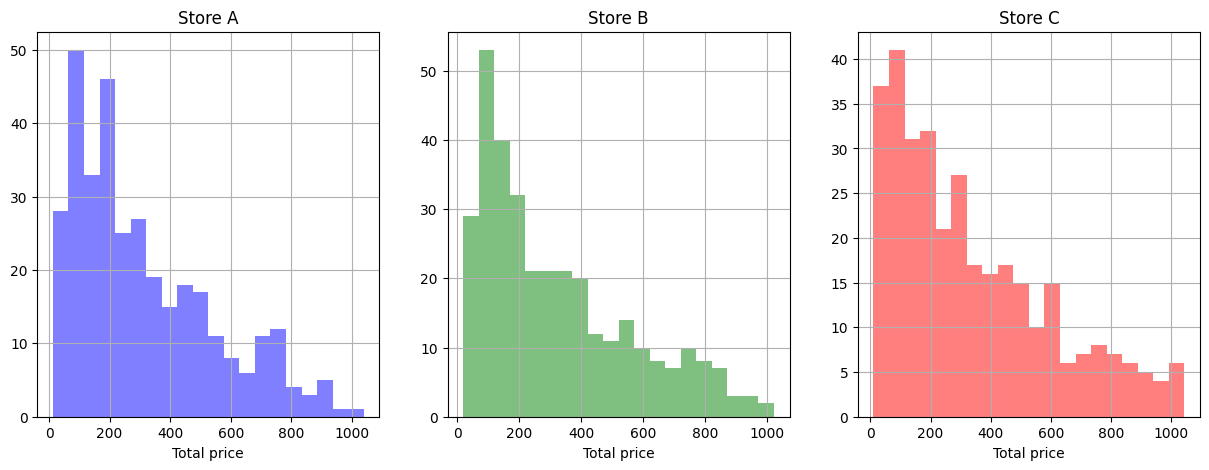

In [14]:
plt.figure(figsize=(15,5))
for i, b in enumerate(['A', 'B', 'C']):
    plt.subplot(1, 3, i+1)
    plt.hist(stores[b]['Total'].values, bins=20, 
                 color=list(mcolors.BASE_COLORS.values())[i], alpha=0.5)
    plt.title("Store {}".format(b))
    plt.xlabel('Total price')
    plt.grid()
plt.show()

Теперь как истинные байесяне, давайте введем вероятностную модель поррождения данных и будем уточнять ее параметры по мере поступления новой информации.

**Вопрос 4.1** Каким распределением можно было бы описать чеки?

### Экспоненциальное распределение

Это рапределение хорошо подходит для описания непрерывной случайной величины, которая с большей вероятностью принимает значения ближе к нулю

$$p(x | \lambda) = \lambda e^{-\lambda x}, \;\;\; x \geq 0$$

In [15]:
prob_exp = lambda x, l: l * np.exp(-l*x)

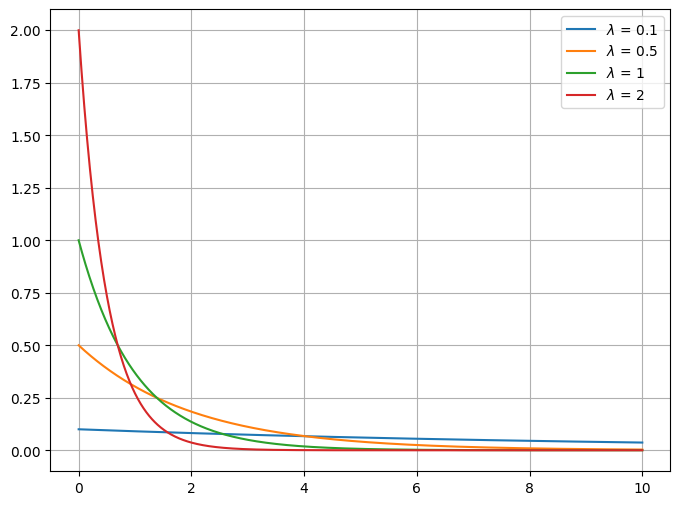

In [16]:
plt.figure(figsize=(8,6))
x = np.linspace(0, 10, 1000)
for l in [0.1, 0.5, 1, 2]:
    plt.plot(x, prob_exp(x, l), label=r'$\lambda$ = ' + str(l))
plt.legend()
plt.grid()

Теперь выясним, как связаны средний чек и параметр экспоненциального распределения.

**Вопрос 4.2** Найдите мат.ожидание экспоненциального распределения 

С прадоподобием данных разобрались, теперь давайте подберем какой-нибудь хороший прайер на $\lambda$

**Вопрос 4.3** Какое распределение будет сопряженным к экспоненциальному?

### Гамма-распределение

$$\mathcal{G}(x | a, b) = \frac{b^a}{\Gamma(a)}x^{a-1}\exp(-bx)$$

In [17]:
prob_gamma = lambda x, a, b: np.exp(-b*x + a*np.log(b) - np.log(scipy.special.gamma(a)) + (a-1)*np.log(x))

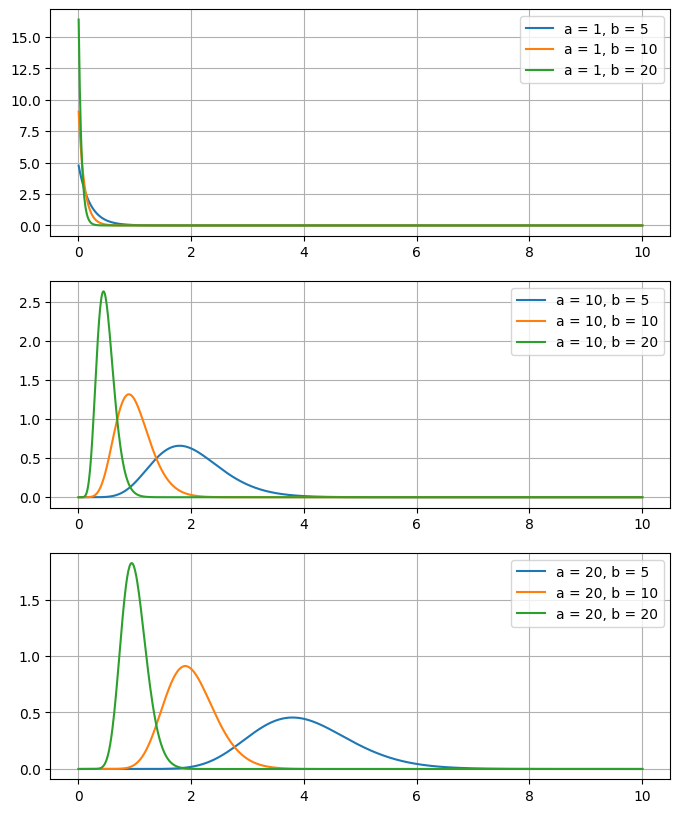

In [18]:
plt.figure(figsize=(8,10))
x = np.linspace(0.01, 10, 1000)
for i, a in enumerate([1, 10, 20]):
    plt.subplot(3, 1, i+1)
    for b in [5, 10, 20]:
        plt.plot(x, prob_gamma(x, a, b), label='a = {}, b = {}'.format(a, b))
    plt.legend()
    plt.grid()

**Вопрос 3.4** Как задать априорные значения a и b, зная, что у конкурентов покупатель в среднем тратит 200-300 долларов?

Пусть $c_{max} = 300$, $c_{min} = 200$, тогда $\lambda_{max} = \frac{1}{c_{min}}$, $\lambda_{min} = \frac{1}{c_{max}}$. Оценим разброс по лямбда как $(\lambda_{max} - \lambda_{min})/2$, a среднее как $(\lambda_{max} + \lambda_{min})/2$. Тогда

$$\mathbb{E}(\lambda) = \frac{\lambda_{max} + \lambda_{min}}{2}$$

$$\mathbb{V}(\lambda) = \Big(\frac{\lambda_{max} - \lambda_{min}}{2}\Big)^2$$

Пользуясь формулой для плотности гамма-распределения, можно выразить мат.ожидание и дисперсию $\lambda$ через a и b:

$$\mathbb{E}(\lambda) = \frac{a}{b}$$

$$\mathbb{V}(\lambda) = \frac{a}{b^2}$$

Тогда:

$$b = \frac{2(\lambda_{max}+\lambda_{min})}{(\lambda_{max}-\lambda_{min})^2}$$

$$a = \Big(\frac{\lambda_{max}+\lambda_{min}}{\lambda_{max}-\lambda_{min}}\Big)^2$$

In [19]:
l_max = 1/200
l_min = 1/300
b_prior = 2*(l_max + l_min) / (l_max - l_min)**2
a_prior = ((l_max + l_min) / (l_max - l_min))**2

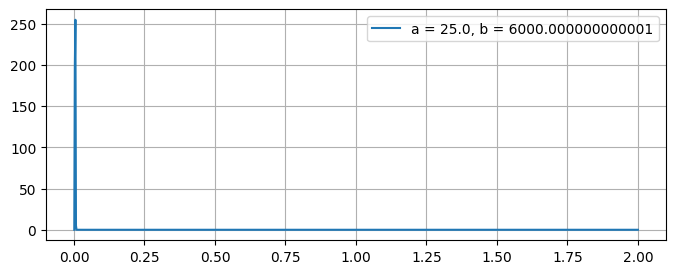

In [20]:
plt.figure(figsize=(8,3))
x = np.linspace(0.001, 2, 1000)
plt.plot(x, prob_gamma(x, a_prior, b_prior), label='a = {}, b = {}'.format(a_prior, b_prior))
plt.legend()
plt.grid()
plt.show()

Итак, найдем апостериорное распределение

**Вопрос 4.5** Найдите апостериорное распределение и его мат.ожидание

In [21]:
def get_posterior(values, a, b):
    a_post = a + len(values)
    b_post = b + np.sum(values)
    return a_post, b_post

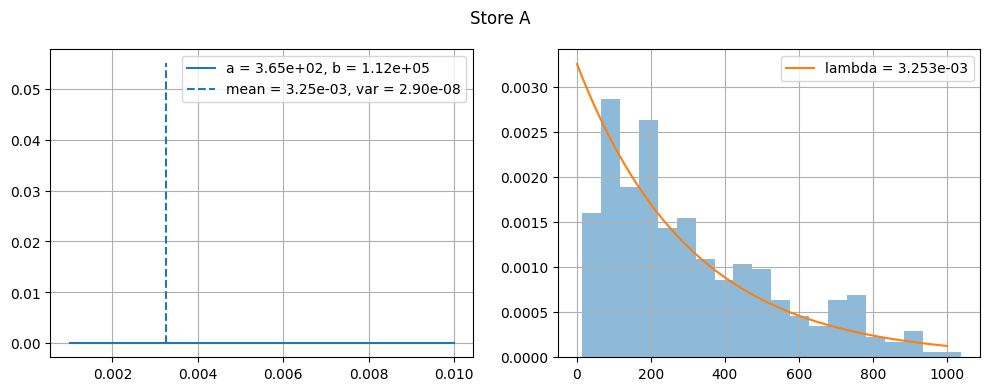

Средний чек: 307.3982753424659


In [22]:
values = stores['A'].Total.values
a = a_prior
b = b_prior
for idx in range (len(values)):
    clear_output(True)
    plt.figure(figsize=(12, 4))
    known_values = values[:idx+1]
    a, b = get_posterior([known_values[-1]], a, b)
    plt.subplot(1,2,1)
    x = np.linspace(0.001, 0.01, 1000)
    plt.plot(x, prob_gamma(x, a, b), label='a = {0:.2e}, b = {1:.2e}'.format(a, b))
    lambda_bayes = a/b
    plt.vlines(lambda_bayes, 0, plt.gca().get_ylim()[1], linestyle='--', label='mean = {0:.2e}, var = {1:.2e}'.format(a/b, a/b**2))
    plt.grid(True)
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(known_values,  bins=20, alpha=0.5, density=True)
    x = np.linspace(0.01, 1000, 2000)
    plt.plot(x, prob_exp(x, lambda_bayes), label='lambda = {0:.3e}'.format(lambda_bayes))
    plt.grid(True)
    plt.legend()
    plt.suptitle('Store A')
    plt.show()
    print("Средний чек: {}".format(1/lambda_bayes))

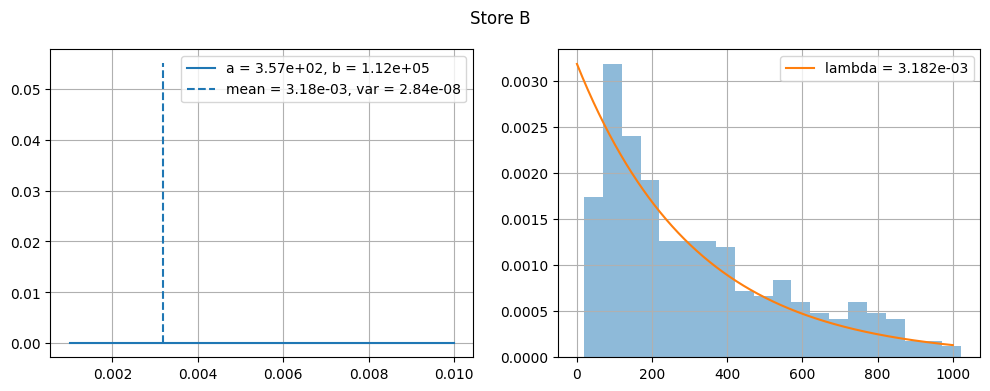

Средний чек: 314.2791932773111


In [23]:
values = stores['B'].Total.values
a = a_prior
b = b_prior
for idx in range (len(values)):
    clear_output(True)
    plt.figure(figsize=(12, 4))
    known_values = values[:idx+1]
    a, b = get_posterior([known_values[-1]], a, b)
    plt.subplot(1,2,1)
    x = np.linspace(0.001, 0.01, 1000)
    plt.plot(x, prob_gamma(x, a, b), label='a = {0:.2e}, b = {1:.2e}'.format(a, b))
    lambda_bayes = a/b
    plt.vlines(lambda_bayes, 0, plt.gca().get_ylim()[1], linestyle='--', label='mean = {0:.2e}, var = {1:.2e}'.format(a/b, a/b**2))
    plt.grid(True)
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(known_values,  bins=20, alpha=0.5, density=True)
    x = np.linspace(0.01, 1000, 2000)
    plt.plot(x, prob_exp(x, lambda_bayes), label='lambda = {0:.3e}'.format(lambda_bayes))
    plt.grid(True)
    plt.legend()
    plt.suptitle('Store B')
    plt.show()
    print("Средний чек: {}".format(1/lambda_bayes))

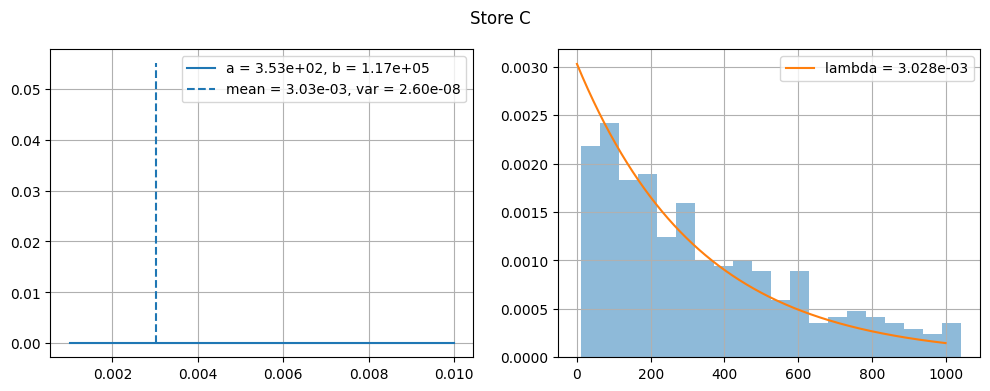

Средний чек: 330.22296458923495


In [24]:
values = stores['C'].Total.values
a = a_prior
b = b_prior
for idx in range (len(values)):
    clear_output(True)
    plt.figure(figsize=(12, 4))
    known_values = values[:idx+1]
    a, b = get_posterior([known_values[-1]], a, b)
    plt.subplot(1,2,1)
    x = np.linspace(0.001, 0.01, 1000)
    plt.plot(x, prob_gamma(x, a, b), label='a = {0:.2e}, b = {1:.2e}'.format(a, b))
    lambda_bayes = a/b
    plt.vlines(lambda_bayes, 0, plt.gca().get_ylim()[1], linestyle='--', label='mean = {0:.2e}, var = {1:.2e}'.format(a/b, a/b**2))
    plt.grid(True)
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(known_values,  bins=20, alpha=0.5, density=True)
    x = np.linspace(0.01, 1000, 2000)
    plt.plot(x, prob_exp(x, lambda_bayes), label='lambda = {0:.3e}'.format(lambda_bayes))
    plt.grid(True)
    plt.legend()
    plt.suptitle('Store C')
    plt.show()
    print("Средний чек: {}".format(1/lambda_bayes))